In [1]:
import pandas as pd

df = pd.read_parquet("../../data/processed_data/analysis_panel.parquet")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:\n{df.head(3).to_string()}")

Shape: (16576, 35)

Columns:
['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'IS8_SECTOR', 'EMPLOYEES', 'BUSINESSES', 'unemployment_rate', 'transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband', 'coverage_4g', 'gcse_age19', 'apprenticeship_starts', 'apprenticeship_achievements', 'nvq_level3', 'fe_participation', 'housing_net_additions', 'enterprise_birth_rate', 'enterprise_death_rate', 'enterprise_high_growth_rate', 'REGION', 'COUNTY_UA', 'n_universities_feecap_lad', 'lq_bus', 'emp_share', 'lq_emp', 'gd_emp', 'gd_bus', 'n_years_emp', 'n_years_bus', 'related_variety', 'within_sector_diversity', 'size_large_share', 'size_micro_share']

First 3 rows:
   YEAR GEOGRAPHY_CODE GEOGRAPHY_NAME              IS8_SECTOR  EMPLOYEES  BUSINESSES  unemployment_rate  transport_to_employer  drive_to_employer  cycle_to_employer  broadband  coverage_4g  gcse_age19  apprenticeship_starts  apprenticeship_achievements  nvq_level3  fe_participation  housing_net_additions  enterprise_birth

In [2]:
import pandas as pd

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nYear range: {df['YEAR'].min()} – {df['YEAR'].max()}")
print(f"Unique LADs: {df['GEOGRAPHY_CODE'].nunique()}")
print(f"Unique INDUSTRY_CODEs: {df['INDUSTRY_CODE'].nunique()}")
print(f"Unique IS8_SECTORs: {df['IS8_SECTOR'].unique().tolist()}")
print(f"Unique FRONTIER_SECTORs: {df['FRONTIER_SECTOR'].dropna().unique().tolist()}")
print(f"\nSample rows (one per IS8 sector):")
print(df.groupby('IS8_SECTOR').first().reset_index()[['YEAR','GEOGRAPHY_CODE','GEOGRAPHY_NAME','IS8_SECTOR','FRONTIER_SECTOR','INDUSTRY_CODE','OBS_VALUE']].to_string(index=False))

Shape: (312400, 8)

Columns: ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'GEOGRAPHY_TYPE', 'IS8_SECTOR', 'FRONTIER_SECTOR', 'INDUSTRY_CODE', 'OBS_VALUE']

Dtypes:
YEAR               int16
GEOGRAPHY_CODE       str
GEOGRAPHY_NAME       str
GEOGRAPHY_TYPE       str
IS8_SECTOR           str
FRONTIER_SECTOR      str
INDUSTRY_CODE        str
OBS_VALUE          Int64
dtype: object

Year range: 2015 – 2024
Unique LADs: 355
Unique INDUSTRY_CODEs: 85
Unique IS8_SECTORs: ['Advanced manufacturing', 'Creative Industries', 'Defence sector', 'Digital and Technology', 'Financial Services', 'Life Sciences', 'Professional and Business Services', 'Total']
Unique FRONTIER_SECTORs: ['Aerospace manufacturing', 'Agritech', 'Automotive manufacturing', 'Batteries', 'Advertising and marketing', 'Film and TV', 'Music, peforming, and visual arts', 'Video games', 'Asset management and wholesale services', 'Capital markets and retail investment', 'Insurance and reinsurance markets', 'Accounting, audit and tax cons

In [3]:
import pandas as pd

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

# Filter to 2023, LAD level, frontier sectors only, non-zero employment
lad_type = "local authorities: district / unitary (as of April 2023)"
frontier = (df[
    (df["YEAR"] == 2023) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["FRONTIER_SECTOR"].notna()) &
    (df["OBS_VALUE"] > 0)
]).copy()

# Aggregate by LAD × frontier sector
agg = frontier.groupby(["FRONTIER_SECTOR", "IS8_SECTOR"])["GEOGRAPHY_CODE"].nunique().reset_index()
agg.columns = ["frontier_sector", "IS8_sector", "n_lads_with_employment"]
agg = agg.sort_values("n_lads_with_employment", ascending=False)

print("=== Frontier sector presence in 2023 (LADs with non-zero employment) ===")
print(f"Total LADs in dataset: {df[df['GEOGRAPHY_TYPE']==lad_type]['GEOGRAPHY_CODE'].nunique()}")
print()
print(agg.to_string(index=False))

=== Frontier sector presence in 2023 (LADs with non-zero employment) ===
Total LADs in dataset: 350

                        frontier_sector                         IS8_sector  n_lads_with_employment
  Accounting, audit and tax consultancy Professional and Business Services                     349
              Advertising and marketing                Creative Industries                     349
Asset management and wholesale services                 Financial Services                     349
                 Management consultancy Professional and Business Services                     349
      Music, peforming, and visual arts                Creative Industries                     349
  Capital markets and retail investment                 Financial Services                     349
                         Legal services Professional and Business Services                     349
                            Film and TV                Creative Industries                     347
      In

In [4]:
import pandas as pd

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_LADS = {
    "E08000019": "Sheffield",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000016": "Barnsley"
}

lad_type = "local authorities: district / unitary (as of April 2023)"

sy = (df[
    (df["YEAR"] == 2023) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS)) &
    (df["FRONTIER_SECTOR"].notna())
]).copy()

sy["LAD"] = sy["GEOGRAPHY_CODE"].map(SY_LADS)

# Aggregate employment by LAD × frontier sector
agg = (sy.groupby(["FRONTIER_SECTOR", "IS8_SECTOR", "LAD"])["OBS_VALUE"]
         .sum()
         .reset_index()
         .pivot(index=["FRONTIER_SECTOR", "IS8_SECTOR"], columns="LAD", values="OBS_VALUE")
         .reset_index()
         .sort_values("FRONTIER_SECTOR"))

agg["SY_total"] = agg[["Sheffield", "Doncaster", "Rotherham", "Barnsley"]].sum(axis=1)
agg = agg.sort_values("SY_total", ascending=False)

print("=== SY frontier sector employment (2023) ===")
print(agg.to_string(index=False))

=== SY frontier sector employment (2023) ===
                        FRONTIER_SECTOR                         IS8_SECTOR  Barnsley  Doncaster  Rotherham  Sheffield  SY_total
  Capital markets and retail investment                 Financial Services       480        775       1190       4820      7265
                         Legal services Professional and Business Services       450        700        300       4500      5950
Asset management and wholesale services                 Financial Services       610       1760        500       2600      5470
                 Management consultancy Professional and Business Services       800        700        700       3000      5200
  Accounting, audit and tax consultancy Professional and Business Services       700        600        350       2000      3650
      Insurance and reinsurance markets                 Financial Services        75        650        185        660      1570
               Automotive manufacturing             Advance

In [5]:
import pandas as pd

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_LADS = {
    "E08000019": "Sheffield",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000016": "Barnsley"
}

lad_type  = "local authorities: district / unitary (as of April 2023)"
benchmark = "Great Britain"
year      = 2023

# --- LAD total employment (from Total row) ---
lad_total = (df[
    (df["YEAR"] == year) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["IS8_SECTOR"] == "Total") &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS))
].groupby("GEOGRAPHY_CODE")["OBS_VALUE"].sum()
  .rename("LAD_TOTAL"))

# --- National total employment ---
nat_total = df[
    (df["YEAR"] == year) &
    (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["IS8_SECTOR"] == "Total")
]["OBS_VALUE"].sum()

# --- LAD frontier employment ---
lad_frontier = (df[
    (df["YEAR"] == year) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS)) &
    (df["FRONTIER_SECTOR"].notna())
].groupby(["GEOGRAPHY_CODE", "FRONTIER_SECTOR"])["OBS_VALUE"].sum()
  .reset_index()
  .rename(columns={"OBS_VALUE": "LAD_FRONTIER_EMP"}))

# --- National frontier employment ---
nat_frontier = (df[
    (df["YEAR"] == year) &
    (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["FRONTIER_SECTOR"].notna())
].groupby("FRONTIER_SECTOR")["OBS_VALUE"].sum()
  .reset_index()
  .rename(columns={"OBS_VALUE": "NAT_FRONTIER_EMP"}))

# --- Compute LQ ---
lad_frontier = lad_frontier.merge(lad_total, on="GEOGRAPHY_CODE")
lad_frontier = lad_frontier.merge(nat_frontier, on="FRONTIER_SECTOR")
lad_frontier["NAT_TOTAL"] = nat_total
lad_frontier["lq_frontier"] = (
    (lad_frontier["LAD_FRONTIER_EMP"] / lad_frontier["LAD_TOTAL"]) /
    (lad_frontier["NAT_FRONTIER_EMP"] / lad_frontier["NAT_TOTAL"])
)
lad_frontier["LAD"] = lad_frontier["GEOGRAPHY_CODE"].map(SY_LADS)

# Pivot for readability
out = (lad_frontier.pivot(index="FRONTIER_SECTOR", columns="LAD", values="lq_frontier")
                   .reset_index()
                   .sort_values("Sheffield", ascending=False))

print("=== SY frontier sector LQ (2023) ===")
print(out.to_string(index=False))

=== SY frontier sector LQ (2023) ===
                        FRONTIER_SECTOR  Barnsley  Doncaster  Rotherham  Sheffield
                         Legal services   0.52155   0.536087   0.312391   1.679411
                               Agritech   1.54478   4.253136   0.925271   1.658085
  Capital markets and retail investment  0.400036   0.426789   0.891042   1.293498
      Music, peforming, and visual arts  0.324995   0.195226   0.106179   0.903792
                 Management consultancy  0.553472   0.320006   0.435108   0.668326
              Advertising and marketing  0.300374    0.13232   0.287862   0.606122
Asset management and wholesale services  0.401963   0.766342   0.296019   0.551685
                            Video games  0.136018        0.0   0.305514   0.547481
  Accounting, audit and tax consultancy  0.536838   0.304054   0.241161   0.493898
      Insurance and reinsurance markets  0.137436   0.787057   0.304582   0.389443
                Aerospace manufacturing       0.0 

In [6]:
import pandas as pd
import numpy as np
from scipy import stats

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_LADS = {
    "E08000019": "Sheffield",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000016": "Barnsley"
}

lad_type  = "local authorities: district / unitary (as of April 2023)"
benchmark = "Great Britain"
y0, y1    = 2016, 2023

def ols_slope(years, values):
    mask = (values > 0) & np.isfinite(values)
    x, y = years[mask], values[mask]
    if len(x) < 4:
        return np.nan
    slope, _, _, _, _ = stats.linregress(x, np.log(y))
    return slope

# --- LAD frontier employment time series ---
lad_ts = (df[
    (df["YEAR"] >= y0) & (df["YEAR"] <= y1) &
    (df["GEOGRAPHY_TYPE"] == lad_type) &
    (df["GEOGRAPHY_CODE"].isin(SY_LADS)) &
    (df["FRONTIER_SECTOR"].notna())
].groupby(["GEOGRAPHY_CODE", "FRONTIER_SECTOR", "YEAR"])["OBS_VALUE"]
  .sum().reset_index())

# --- National frontier employment time series ---
nat_ts = (df[
    (df["YEAR"] >= y0) & (df["YEAR"] <= y1) &
    (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["FRONTIER_SECTOR"].notna())
].groupby(["FRONTIER_SECTOR", "YEAR"])["OBS_VALUE"]
  .sum().reset_index())

# --- National slopes ---
nat_slopes = {}
for sector, grp in nat_ts.groupby("FRONTIER_SECTOR"):
    grp = grp.sort_values("YEAR")
    nat_slopes[sector] = ols_slope(grp["YEAR"].values, grp["OBS_VALUE"].values.astype(float))

# --- LAD slopes and GD ---
records = []
for (geo, sector), grp in lad_ts.groupby(["GEOGRAPHY_CODE", "FRONTIER_SECTOR"]):
    grp = grp.sort_values("YEAR")
    beta_lad = ols_slope(grp["YEAR"].values, grp["OBS_VALUE"].values.astype(float))
    beta_nat = nat_slopes.get(sector, np.nan)
    gd = beta_lad - beta_nat if (not np.isnan(beta_nat) and beta_nat != 0) else np.nan
    records.append({
        "GEOGRAPHY_CODE": geo,
        "LAD": SY_LADS[geo],
        "FRONTIER_SECTOR": sector,
        "beta_lad": round(beta_lad, 4) if not np.isnan(beta_lad) else np.nan,
        "beta_nat": round(beta_nat, 4) if not np.isnan(beta_nat) else np.nan,
        "gd_emp": round(gd, 4) if not np.isnan(gd) else np.nan
    })

gd = pd.DataFrame(records)

# Pivot GD for readability
out = (gd.pivot(index="FRONTIER_SECTOR", columns="LAD", values="gd_emp")
         .reset_index()
         .sort_values("Sheffield", ascending=False))

print("=== SY frontier sector GD (2016–2023) ===")
print("Positive = growing faster than national trend")
print()
print(out.to_string(index=False))

# Also show national slopes for context
print("\n=== National growth slopes by frontier sector ===")
nat_df = pd.DataFrame([{"FRONTIER_SECTOR": k, "beta_national": round(v,4)} 
                        for k,v in nat_slopes.items()]).sort_values("beta_national", ascending=False)
print(nat_df.to_string(index=False))

=== SY frontier sector GD (2016–2023) ===
Positive = growing faster than national trend

                        FRONTIER_SECTOR  Barnsley  Doncaster  Rotherham  Sheffield
                Aerospace manufacturing       NaN    -0.2968     0.2908     0.3158
                               Agritech    0.1029     0.0898     0.2941     0.0884
              Advertising and marketing   -0.0206    -0.0350     0.0335     0.0472
                            Video games   -0.1279        NaN     0.1094     0.0307
                         Legal services    0.0348    -0.0273    -0.0430     0.0048
  Accounting, audit and tax consultancy    0.1143     0.0516     0.0181    -0.0001
  Capital markets and retail investment   -0.0577     0.0981    -0.0000    -0.0116
      Music, peforming, and visual arts    0.0028    -0.0516    -0.1769    -0.0142
Asset management and wholesale services    0.0765     0.0067     0.0474    -0.0357
               Automotive manufacturing   -0.0744     0.0700    -0.0682    -0.057

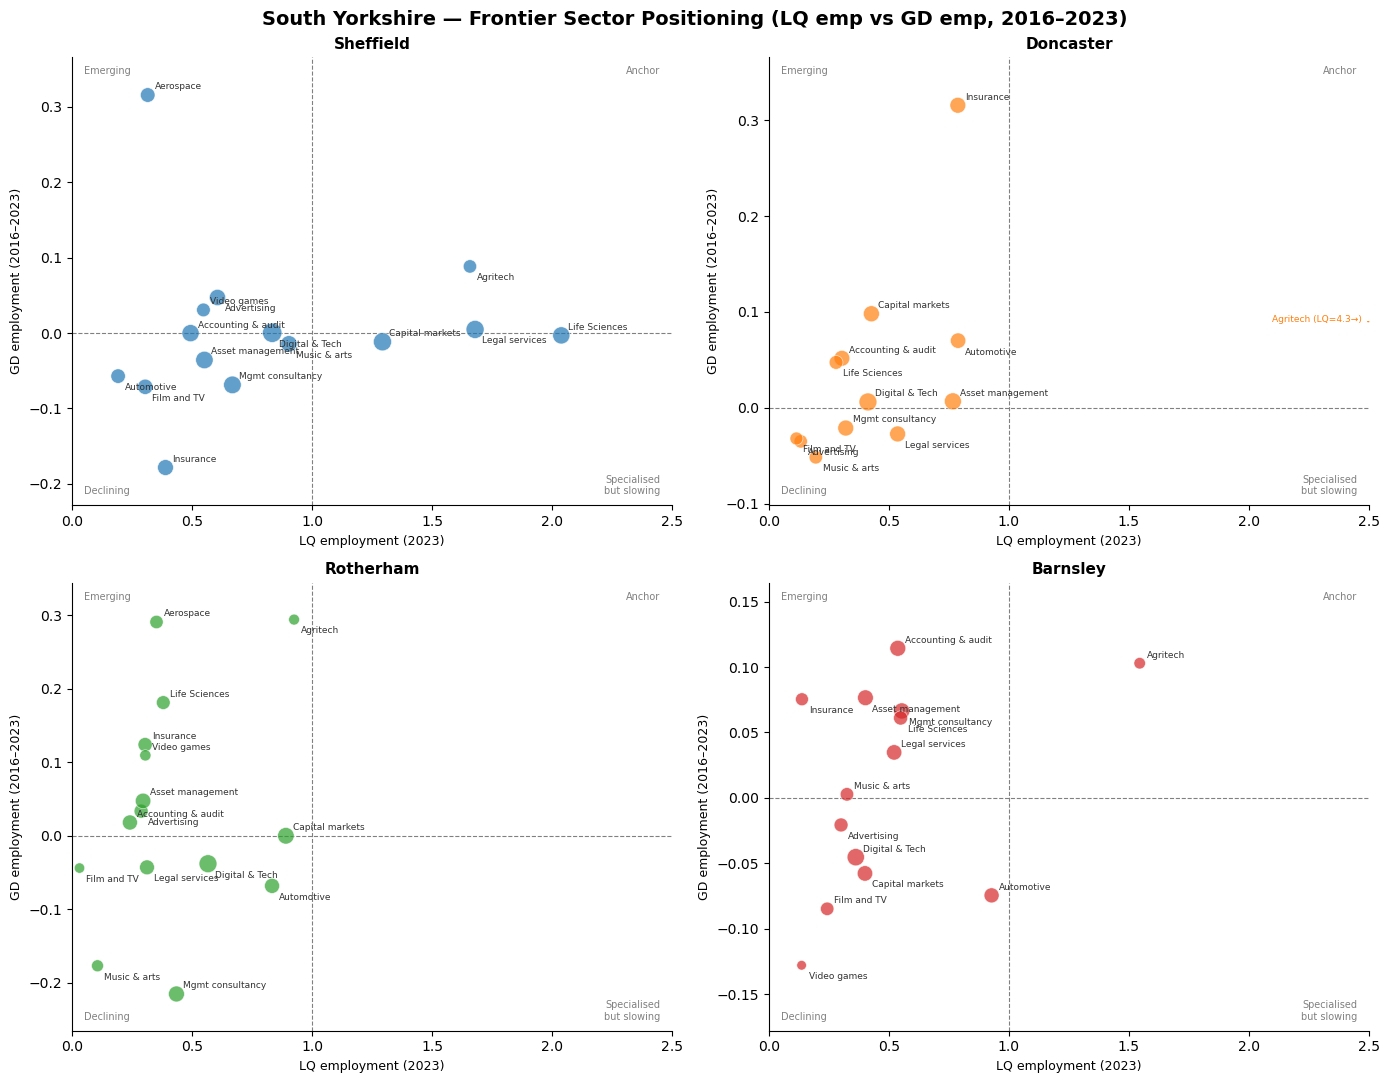

✅ Saved


In [54]:
# ── SY LAD frontier scatter — includes Life Sciences and Digital & Technology ─
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"
OUT = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/output/graphs/franco"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_LADS = {
    "E08000019": "Sheffield",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000016": "Barnsley"
}
LAD_COLORS = {
    "Sheffield":  "#1f77b4",
    "Doncaster":  "#ff7f0e",
    "Rotherham":  "#2ca02c",
    "Barnsley":   "#d62728"
}

lad_type        = "local authorities: district / unitary (as of April 2023)"
benchmark       = "Great Britain"
y0, y1          = 2016, 2023
IS8_AS_FRONTIER = ["Life Sciences", "Digital and Technology"]

def ols_slope(years, values):
    mask = (values > 0) & np.isfinite(values)
    x, y = years[mask], values[mask]
    if len(x) < 4:
        return np.nan
    slope, *_ = stats.linregress(x, np.log(y))
    return slope

# ── LQ ────────────────────────────────────────────────────────────────────────
lad_total = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["IS8_SECTOR"] == "Total") & (df["GEOGRAPHY_CODE"].isin(SY_LADS))]
    .groupby("GEOGRAPHY_CODE")["OBS_VALUE"].sum().rename("LAD_TOTAL")
)
nat_total = df[
    (df["YEAR"] == y1) & (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["IS8_SECTOR"] == "Total")
]["OBS_VALUE"].sum()

# Frontier sectors
lad_front = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["GEOGRAPHY_CODE"].isin(SY_LADS)) & (df["FRONTIER_SECTOR"].notna())]
    .groupby(["GEOGRAPHY_CODE", "FRONTIER_SECTOR"])["OBS_VALUE"].sum().reset_index()
    .rename(columns={"FRONTIER_SECTOR": "sector"})
)
nat_front = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_NAME"] == benchmark) &
       (df["FRONTIER_SECTOR"].notna())]
    .groupby("FRONTIER_SECTOR")["OBS_VALUE"].sum().reset_index()
    .rename(columns={"FRONTIER_SECTOR": "sector", "OBS_VALUE": "NAT_EMP"})
)

# IS8-level for Life Sciences + Digital
lad_is8 = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["GEOGRAPHY_CODE"].isin(SY_LADS)) & (df["IS8_SECTOR"].isin(IS8_AS_FRONTIER))]
    .groupby(["GEOGRAPHY_CODE", "IS8_SECTOR"])["OBS_VALUE"].sum().reset_index()
    .rename(columns={"IS8_SECTOR": "sector"})
)
nat_is8 = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_NAME"] == benchmark) &
       (df["IS8_SECTOR"].isin(IS8_AS_FRONTIER))]
    .groupby("IS8_SECTOR")["OBS_VALUE"].sum().reset_index()
    .rename(columns={"IS8_SECTOR": "sector", "OBS_VALUE": "NAT_EMP"})
)

lq = (
    pd.concat([lad_front, lad_is8])
    .merge(lad_total, on="GEOGRAPHY_CODE")
    .merge(pd.concat([nat_front, nat_is8]), on="sector")
)
lq["NAT_TOTAL"] = nat_total
lq["lq"] = (lq["OBS_VALUE"] / lq["LAD_TOTAL"]) / (lq["NAT_EMP"] / lq["NAT_TOTAL"])
lq["LAD"] = lq["GEOGRAPHY_CODE"].map(SY_LADS)
lq = lq.rename(columns={"sector": "FRONTIER_SECTOR"})

# ── GD ────────────────────────────────────────────────────────────────────────
lad_ts = (
    df[(df["YEAR"].between(y0, y1)) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["GEOGRAPHY_CODE"].isin(SY_LADS)) & (df["FRONTIER_SECTOR"].notna())]
    .groupby(["GEOGRAPHY_CODE", "FRONTIER_SECTOR", "YEAR"])["OBS_VALUE"].sum().reset_index()
    .rename(columns={"FRONTIER_SECTOR": "sector"})
)
lad_ts_is8 = (
    df[(df["YEAR"].between(y0, y1)) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["GEOGRAPHY_CODE"].isin(SY_LADS)) & (df["IS8_SECTOR"].isin(IS8_AS_FRONTIER))]
    .groupby(["GEOGRAPHY_CODE", "IS8_SECTOR", "YEAR"])["OBS_VALUE"].sum().reset_index()
    .rename(columns={"IS8_SECTOR": "sector"})
)
nat_ts = (
    df[(df["YEAR"].between(y0, y1)) & (df["GEOGRAPHY_NAME"] == benchmark) &
       (df["FRONTIER_SECTOR"].notna())]
    .groupby(["FRONTIER_SECTOR", "YEAR"])["OBS_VALUE"].sum().reset_index()
    .rename(columns={"FRONTIER_SECTOR": "sector"})
)
nat_ts_is8 = (
    df[(df["YEAR"].between(y0, y1)) & (df["GEOGRAPHY_NAME"] == benchmark) &
       (df["IS8_SECTOR"].isin(IS8_AS_FRONTIER))]
    .groupby(["IS8_SECTOR", "YEAR"])["OBS_VALUE"].sum().reset_index()
    .rename(columns={"IS8_SECTOR": "sector"})
)

all_nat_ts = pd.concat([nat_ts, nat_ts_is8])
nat_slopes = {
    s: ols_slope(g["YEAR"].values, g["OBS_VALUE"].values.astype(float))
    for s, g in all_nat_ts.groupby("sector")
}

gd_records = []
for (geo, sector), grp in pd.concat([lad_ts, lad_ts_is8]).groupby(["GEOGRAPHY_CODE", "sector"]):
    beta     = ols_slope(grp["YEAR"].values, grp["OBS_VALUE"].values.astype(float))
    beta_nat = nat_slopes.get(sector, np.nan)
    gd       = beta - beta_nat if (np.isfinite(beta) and np.isfinite(beta_nat)) else np.nan
    gd_records.append({"GEOGRAPHY_CODE": geo, "FRONTIER_SECTOR": sector, "gd": gd})

gd_df = pd.DataFrame(gd_records)
gd_df["LAD"] = gd_df["GEOGRAPHY_CODE"].map(SY_LADS)

# ── Merge ─────────────────────────────────────────────────────────────────────
merged = (
    lq[["LAD", "FRONTIER_SECTOR", "lq", "OBS_VALUE"]]
    .merge(gd_df[["LAD", "FRONTIER_SECTOR", "gd"]], on=["LAD", "FRONTIER_SECTOR"])
    .dropna(subset=["lq", "gd"])
)
merged = merged[merged["OBS_VALUE"] > 0]

LABEL_MAP = {
    "Accounting, audit and tax consultancy":  "Accounting & audit",
    "Advertising and marketing":              "Advertising",
    "Asset management and wholesale services":"Asset management",
    "Capital markets and retail investment":  "Capital markets",
    "Insurance and reinsurance markets":      "Insurance",
    "Music, peforming, and visual arts":      "Music & arts",
    "Automotive manufacturing":               "Automotive",
    "Aerospace manufacturing":                "Aerospace",
    "Management consultancy":                 "Mgmt consultancy",
    "Life Sciences":                          "Life Sciences",
    "Digital and Technology":                 "Digital & Tech",
}
merged["label"] = merged["FRONTIER_SECTOR"].replace(LABEL_MAP)

# ── Plot ──────────────────────────────────────────────────────────────────────
X_CAP = 2.5

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("South Yorkshire — Frontier Sector Positioning (LQ emp vs GD emp, 2016–2023)",
             fontsize=14, fontweight="bold")

for ax, (lad_name, color) in zip(axes.flat, LAD_COLORS.items()):
    sub      = merged[merged["LAD"] == lad_name].copy()
    outliers = sub[sub["lq"] > X_CAP]
    sub_plot = sub[sub["lq"] <= X_CAP]

    ax.axvline(1, color="grey", linewidth=0.8, linestyle="--", zorder=1)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", zorder=1)

    sizes = np.log1p(sub_plot["OBS_VALUE"]) * 20
    ax.scatter(sub_plot["lq"], sub_plot["gd"], s=sizes,
               color=color, alpha=0.7, edgecolors="white", linewidths=0.5, zorder=3)

    for i, (_, row) in enumerate(sub_plot.iterrows()):
        offset = (5, 4) if i % 2 == 0 else (5, -10)
        ax.annotate(row["label"], xy=(row["lq"], row["gd"]),
                    xytext=offset, textcoords="offset points",
                    fontsize=6.5, color="#333333")

    for _, row in outliers.iterrows():
        ax.annotate(f"{row['label']} (LQ={row['lq']:.1f}→)",
                    xy=(X_CAP, row["gd"]),
                    xytext=(-5, 0), textcoords="offset points",
                    fontsize=6.5, color=color, ha="right",
                    arrowprops=dict(arrowstyle="-", color=color, lw=0.8))

    ax.set_xlim(0, X_CAP)
    ypad = 0.05
    ax.set_ylim(sub_plot["gd"].min() - ypad, sub_plot["gd"].max() + ypad)

    ax.text(0.02, 0.98, "Emerging",            transform=ax.transAxes, fontsize=7, color="grey", va="top")
    ax.text(0.98, 0.98, "Anchor",              transform=ax.transAxes, fontsize=7, color="grey", va="top", ha="right")
    ax.text(0.02, 0.02, "Declining",           transform=ax.transAxes, fontsize=7, color="grey", va="bottom")
    ax.text(0.98, 0.02, "Specialised\nbut slowing", transform=ax.transAxes, fontsize=7, color="grey", va="bottom", ha="right")

    ax.set_title(lad_name, fontweight="bold", fontsize=11)
    ax.set_xlabel("LQ employment (2023)", fontsize=9)
    ax.set_ylabel("GD employment (2016–2023)", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUT}/sy_frontier_quadrant_updated.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved")

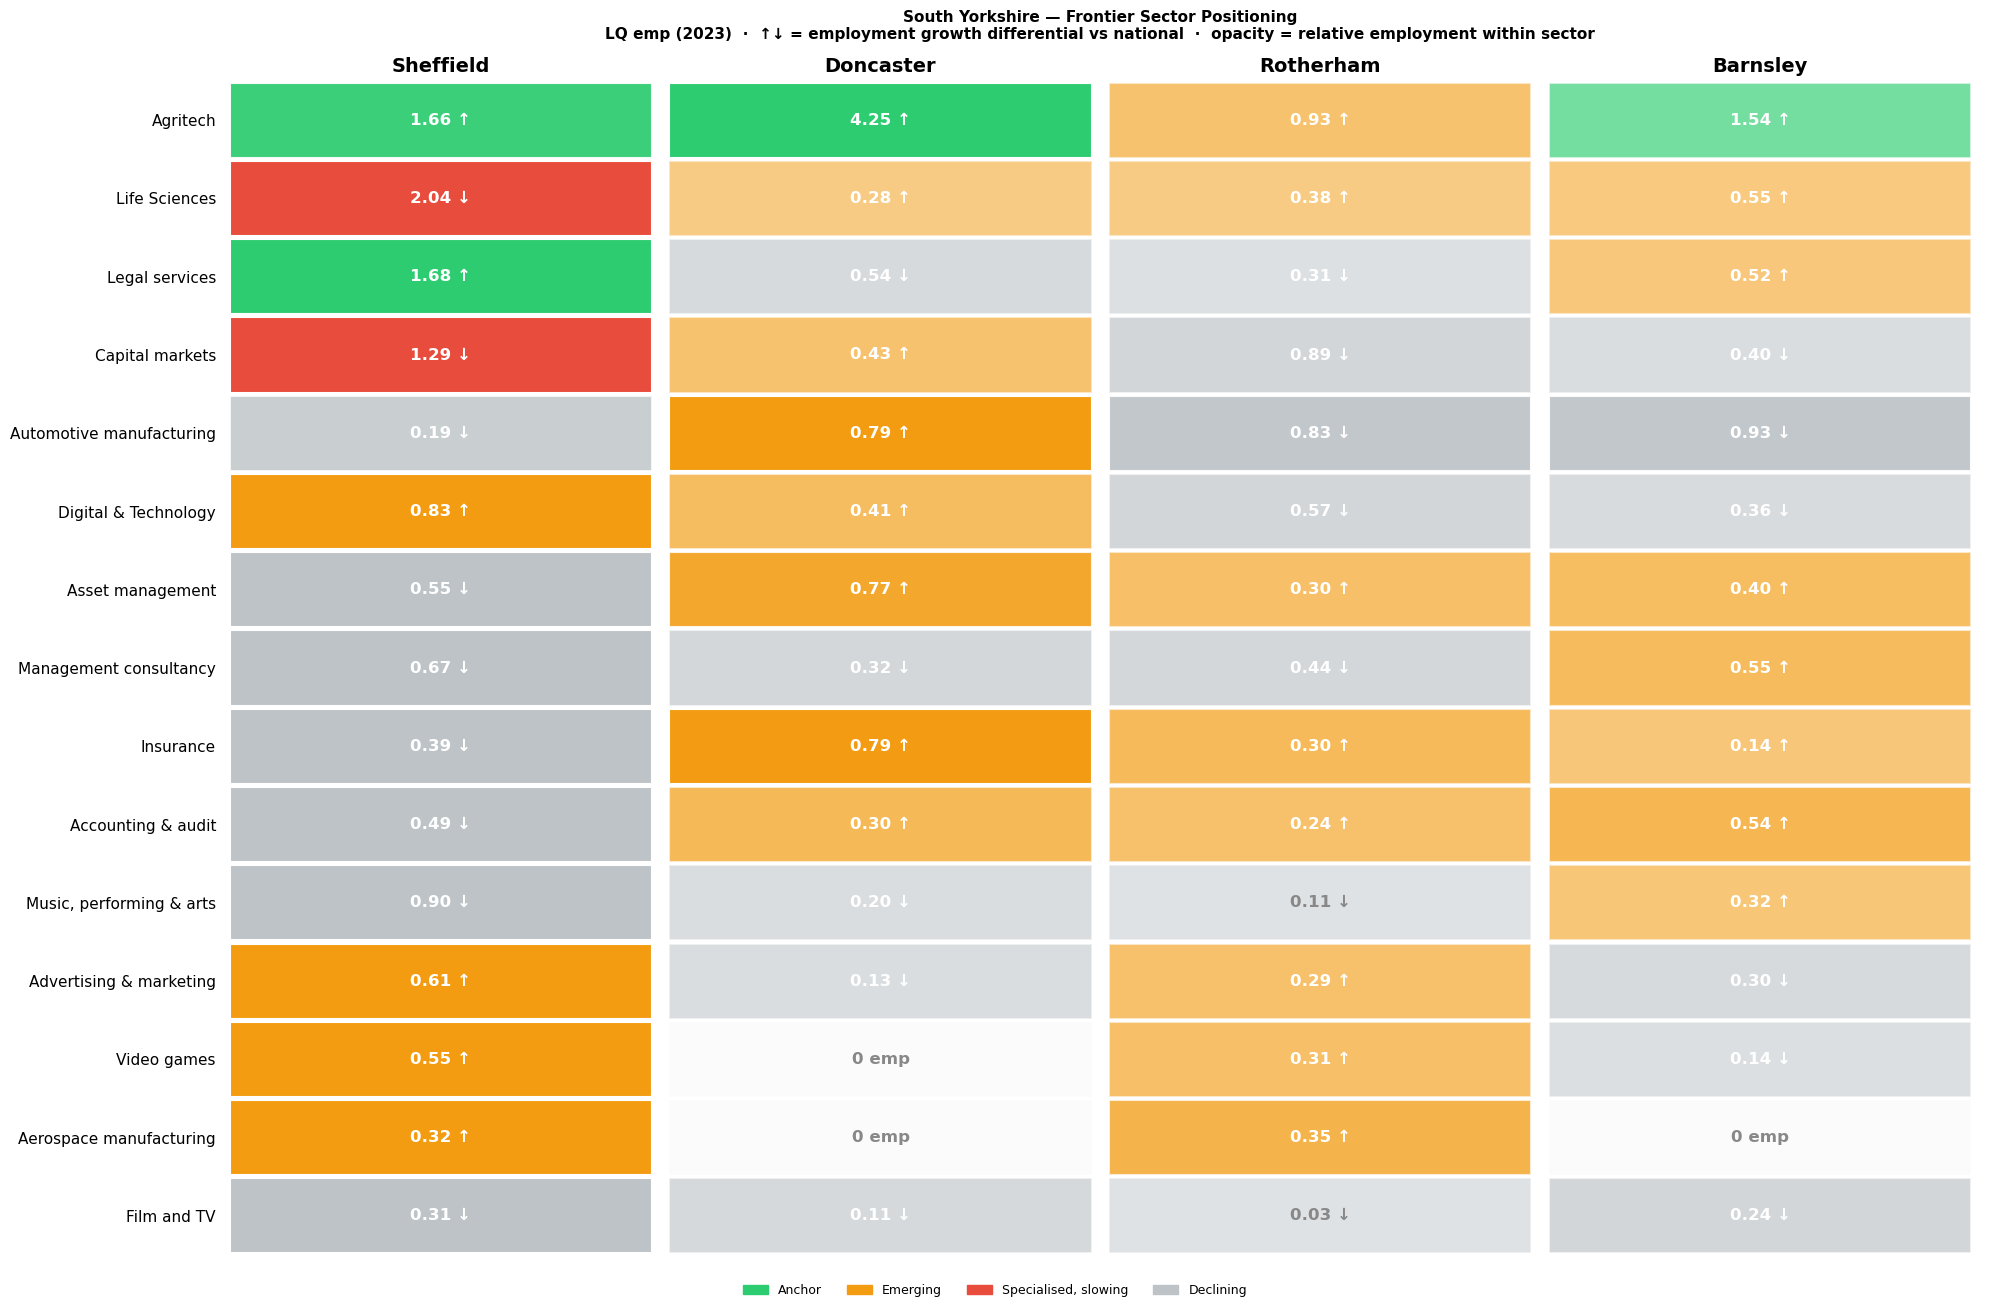

✅ Saved: /Users/francosebastiani/Documents/GitHub/Economic_Observatory/output/graphs/franco/sy_frontier_heatmap_emp.png


In [ ]:
# Replace the plotting loop with row-normalised opacity
# All other code stays the same — just swap this section

# ── Row-normalised max employment per sector ──────────────────────────────────
row_max = (
    hmap.groupby("FRONTIER_SECTOR")["OBS_VALUE"].max()
    .rename("row_max")
)
hmap = hmap.merge(row_max, on="FRONTIER_SECTOR")

# ── Plot ──────────────────────────────────────────────────────────────────────
n_rows = len(sector_order)
n_cols = len(LADS)

fig, ax = plt.subplots(figsize=(n_cols * 5.0, n_rows * 0.85))
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-0.5, n_rows - 0.5)
ax.set_aspect("auto")
ax.spines[:].set_visible(False)
ax.tick_params(length=0)

for col, lad in enumerate(LADS):
    for row, sector in enumerate(sector_order):
        sub = hmap[(hmap["LAD"] == lad) & (hmap["FRONTIER_SECTOR"] == sector)]
        if sub.empty or (sub.iloc[0]["OBS_VALUE"] == 0):
            colour, alpha, txt = "#f5f5f5", 0.3, "0 emp"
        else:
            r      = sub.iloc[0]
            colour = QUADRANT_COLOURS[r["quadrant"]]
            alpha  = 0.35 + 0.65 * (r["OBS_VALUE"] / r["row_max"]) ** 0.5
            arrow  = "↑" if r["gd_emp"] > 0 else "↓"
            txt    = f"{r['lq_emp']:.2f} {arrow}"

        rect = plt.Rectangle(
            [col - 0.48, row - 0.48], 0.96, 0.96,
            color=colour, alpha=alpha, ec="white", lw=1.5
        )
        ax.add_patch(rect)
        ax.text(col, row, txt, ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if alpha > 0.5 else "#888")

ax.set_xticks(range(n_cols))
ax.set_xticklabels(LADS, fontsize=14, fontweight="bold")
ax.set_yticks(range(n_rows))
ax.set_yticklabels(short_order, fontsize=11)
ax.xaxis.tick_top()

patches = [mpatches.Patch(color=c, label=l) for l, c in QUADRANT_COLOURS.items()]
fig.legend(handles=patches, loc="lower center", ncol=4,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.03))

ax.set_title(
    "South Yorkshire — Frontier Sector Positioning\n"
    "LQ emp (2023)  ·  ↑↓ = employment growth differential vs national"
    "  ·  opacity = relative employment within sector",
    fontsize=11, fontweight="bold", pad=30
)

plt.tight_layout()
fname = f"{OUTPUT_DIR}/sy_frontier_heatmap_emp.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {fname}")

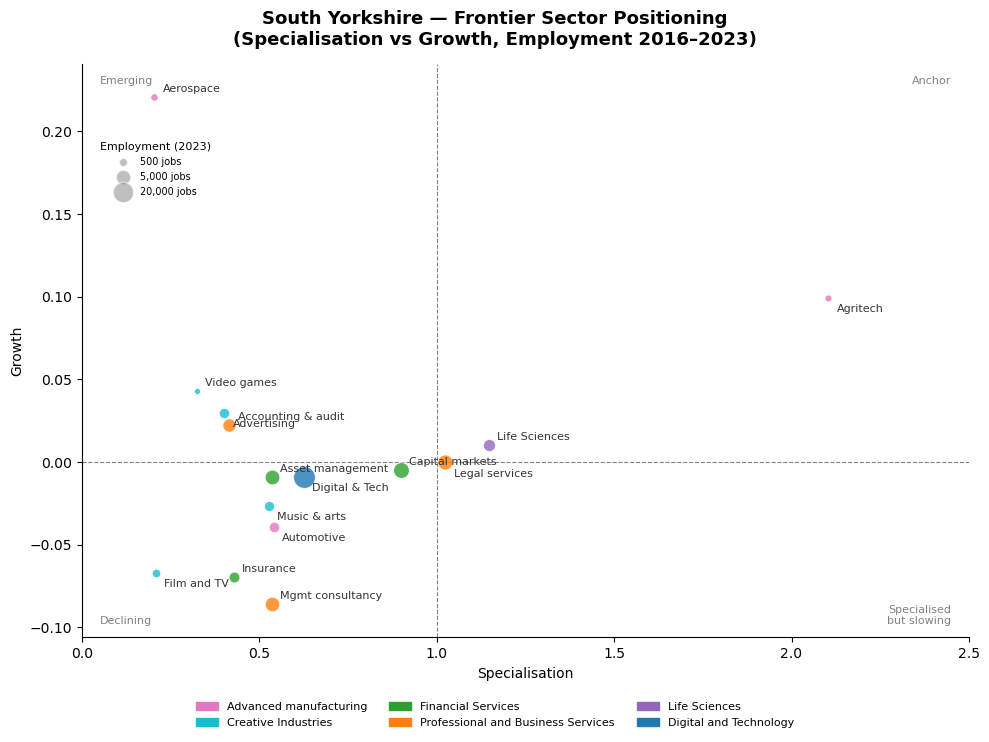

✅ Saved


In [73]:
# ── SY aggregate frontier sector positioning — LQ emp × GD emp ───────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

RAW = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data"
OUT = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/output/graphs/franco"

df = pd.read_parquet(f"{RAW}/employee_counts/Employee_counts_IS8_LADs.parquet")

SY_CODES  = list(SY_LADS.keys())
lad_type  = "local authorities: district / unitary (as of April 2023)"
benchmark = "Great Britain"
y0, y1    = 2016, 2023

IS8_COLOURS = {
    "Advanced manufacturing":             "#e377c2",
    "Creative Industries":                "#17becf",
    "Financial Services":                 "#2ca02c",
    "Professional and Business Services": "#ff7f0e",
    "Life Sciences":                      "#9467bd",
    "Digital and Technology":             "#1f77b4",
}
IS8_AS_FRONTIER = ["Life Sciences", "Digital and Technology"]

def ols_slope(years, values):
    mask = (values > 0) & np.isfinite(values)
    x, y = years[mask], values[mask]
    if len(x) < 4:
        return np.nan
    slope, *_ = stats.linregress(x, np.log(y))
    return slope

# ── LQ emp (2023) ─────────────────────────────────────────────────────────────
sy_total = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["IS8_SECTOR"] == "Total") & (df["GEOGRAPHY_CODE"].isin(SY_CODES))]
    ["OBS_VALUE"].sum()
)
nat_total = df[
    (df["YEAR"] == y1) & (df["GEOGRAPHY_NAME"] == benchmark) &
    (df["IS8_SECTOR"] == "Total")
]["OBS_VALUE"].sum()

sy_front = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["GEOGRAPHY_CODE"].isin(SY_CODES)) & (df["FRONTIER_SECTOR"].notna())]
    .groupby("FRONTIER_SECTOR")["OBS_VALUE"].sum()
    .reset_index().rename(columns={"FRONTIER_SECTOR": "sector", "OBS_VALUE": "SY_EMP"})
)
nat_front = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_NAME"] == benchmark) &
       (df["FRONTIER_SECTOR"].notna())]
    .groupby("FRONTIER_SECTOR")["OBS_VALUE"].sum()
    .reset_index().rename(columns={"FRONTIER_SECTOR": "sector", "OBS_VALUE": "NAT_EMP"})
)
sy_is8 = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["GEOGRAPHY_CODE"].isin(SY_CODES)) & (df["IS8_SECTOR"].isin(IS8_AS_FRONTIER))]
    .groupby("IS8_SECTOR")["OBS_VALUE"].sum()
    .reset_index().rename(columns={"IS8_SECTOR": "sector", "OBS_VALUE": "SY_EMP"})
)
nat_is8 = (
    df[(df["YEAR"] == y1) & (df["GEOGRAPHY_NAME"] == benchmark) &
       (df["IS8_SECTOR"].isin(IS8_AS_FRONTIER))]
    .groupby("IS8_SECTOR")["OBS_VALUE"].sum()
    .reset_index().rename(columns={"IS8_SECTOR": "sector", "OBS_VALUE": "NAT_EMP"})
)

lq_df = (
    pd.concat([sy_front, sy_is8])
    .merge(pd.concat([nat_front, nat_is8]), on="sector")
)
lq_df["lq"] = (lq_df["SY_EMP"] / sy_total) / (lq_df["NAT_EMP"] / nat_total)

# ── GD emp ────────────────────────────────────────────────────────────────────
sy_ts_front = (
    df[(df["YEAR"].between(y0, y1)) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["GEOGRAPHY_CODE"].isin(SY_CODES)) & (df["FRONTIER_SECTOR"].notna())]
    .groupby(["FRONTIER_SECTOR", "YEAR"])["OBS_VALUE"].sum()
    .reset_index().rename(columns={"FRONTIER_SECTOR": "sector"})
)
sy_ts_is8 = (
    df[(df["YEAR"].between(y0, y1)) & (df["GEOGRAPHY_TYPE"] == lad_type) &
       (df["GEOGRAPHY_CODE"].isin(SY_CODES)) & (df["IS8_SECTOR"].isin(IS8_AS_FRONTIER))]
    .groupby(["IS8_SECTOR", "YEAR"])["OBS_VALUE"].sum()
    .reset_index().rename(columns={"IS8_SECTOR": "sector"})
)
nat_ts_front = (
    df[(df["YEAR"].between(y0, y1)) & (df["GEOGRAPHY_NAME"] == benchmark) &
       (df["FRONTIER_SECTOR"].notna())]
    .groupby(["FRONTIER_SECTOR", "YEAR"])["OBS_VALUE"].sum()
    .reset_index().rename(columns={"FRONTIER_SECTOR": "sector"})
)
nat_ts_is8 = (
    df[(df["YEAR"].between(y0, y1)) & (df["GEOGRAPHY_NAME"] == benchmark) &
       (df["IS8_SECTOR"].isin(IS8_AS_FRONTIER))]
    .groupby(["IS8_SECTOR", "YEAR"])["OBS_VALUE"].sum()
    .reset_index().rename(columns={"IS8_SECTOR": "sector"})
)

sy_ts  = pd.concat([sy_ts_front,  sy_ts_is8])
nat_ts = pd.concat([nat_ts_front, nat_ts_is8])

nat_slopes = {
    s: ols_slope(g["YEAR"].values, g["OBS_VALUE"].values.astype(float))
    for s, g in nat_ts.groupby("sector")
}

gd_records = []
for sector, grp in sy_ts.groupby("sector"):
    beta     = ols_slope(grp["YEAR"].values, grp["OBS_VALUE"].values.astype(float))
    beta_nat = nat_slopes.get(sector, np.nan)
    gd       = beta - beta_nat if (np.isfinite(beta) and np.isfinite(beta_nat)) else np.nan
    gd_records.append({"sector": sector, "gd": gd})

gd_df = pd.DataFrame(gd_records)

# ── Merge ─────────────────────────────────────────────────────────────────────
sy_merged = lq_df.merge(gd_df, on="sector").dropna(subset=["lq", "gd"])
sy_merged = sy_merged[sy_merged["SY_EMP"] > 0]

f2is8 = frontier_to_is8.set_index("FRONTIER_SECTOR")["IS8_SECTOR"].to_dict()
for s in IS8_AS_FRONTIER:
    f2is8[s] = s

sy_merged["IS8"]    = sy_merged["sector"].map(f2is8)
sy_merged["colour"] = sy_merged["IS8"].map(IS8_COLOURS).fillna("grey")

LABEL_MAP = {
    "Accounting, audit and tax consultancy":  "Accounting & audit",
    "Advertising and marketing":              "Advertising",
    "Asset management and wholesale services":"Asset management",
    "Capital markets and retail investment":  "Capital markets",
    "Insurance and reinsurance markets":      "Insurance",
    "Music, peforming, and visual arts":      "Music & arts",
    "Automotive manufacturing":               "Automotive",
    "Aerospace manufacturing":                "Aerospace",
    "Management consultancy":                 "Mgmt consultancy",
    "Life Sciences":                          "Life Sciences",
    "Digital and Technology":                 "Digital & Tech",
}
sy_merged["label"] = sy_merged["sector"].replace(LABEL_MAP)

# ── Plot ──────────────────────────────────────────────────────────────────────
X_CAP    = 2.5
outliers = sy_merged[sy_merged["lq"] > X_CAP]
sub      = sy_merged[sy_merged["lq"] <= X_CAP]

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("South Yorkshire — Frontier Sector Positioning\n(Specialisation vs Growth, Employment 2016–2023)",
             fontsize=13, fontweight="bold")

ax.axvline(1, color="grey", linewidth=0.8, linestyle="--", zorder=1)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", zorder=1)

for _, row in sub.iterrows():
    ax.scatter(row["lq"], row["gd"],
               s=np.sqrt(row["SY_EMP"]) * 1.5,
               color=row["colour"], alpha=0.8,
               edgecolors="white", linewidths=0.6, zorder=3)

for i, (_, row) in enumerate(sub.iterrows()):
    offset = (6, 4) if i % 2 == 0 else (6, -10)
    ax.annotate(row["label"], xy=(row["lq"], row["gd"]),
                xytext=offset, textcoords="offset points",
                fontsize=8, color="#333333")

for _, row in outliers.iterrows():
    ax.annotate(f"{row['label']} (LQ={row['lq']:.1f}→)",
                xy=(X_CAP, row["gd"]),
                xytext=(-6, 0), textcoords="offset points",
                fontsize=8, color=row["colour"], ha="right",
                arrowprops=dict(arrowstyle="-", color=row["colour"], lw=0.8))

ax.set_xlim(0, X_CAP)
ypad = 0.02
ax.set_ylim(sub["gd"].min() - ypad, sub["gd"].max() + ypad)

ax.text(0.02, 0.98, "Emerging",                 transform=ax.transAxes, fontsize=8, color="grey", va="top")
ax.text(0.98, 0.98, "Anchor",                   transform=ax.transAxes, fontsize=8, color="grey", va="top", ha="right")
ax.text(0.02, 0.02, "Declining",                transform=ax.transAxes, fontsize=8, color="grey", va="bottom")
ax.text(0.98, 0.02, "Specialised\nbut slowing", transform=ax.transAxes, fontsize=8, color="grey", va="bottom", ha="right")

ax.set_xlabel("Specialisation", fontsize=10)
ax.set_ylabel("Growth", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Bubble size legend
for emp, label in [(500, "500"), (5000, "5,000"), (20000, "20,000")]:
    ax.scatter([], [], s=np.sqrt(emp) * 1.5, color="grey", alpha=0.5,
               edgecolors="white", label=f"{label} jobs")
ax.legend(title="Employment (2023)", loc="upper left",
          fontsize=7, title_fontsize=8, frameon=False,
          bbox_to_anchor=(0.01, 0.88))

patches = [mpatches.Patch(color=c, label=l) for l, c in IS8_COLOURS.items()]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig(f"{OUT}/sy_aggregate_frontier_emp.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved")

In [59]:
# ── Anchor selection: LQ emp ≥ 1 AND LQ bus ≥ 1 ─────────────────────────────
# Requires: merged (LQ emp + GD emp), lq_bus_df (LQ bus for SY LADs)

# Merge LQ bus onto merged df
combined = merged.merge(
    lq_bus_df[["LAD", "FRONTIER_SECTOR", "lq_bus"]],
    on=["LAD", "FRONTIER_SECTOR"],
    how="left"
)

# Anchor condition: both LQ emp ≥ 1 AND LQ bus ≥ 1
combined["is_anchor"] = (combined["lq"] >= 1.0) & (combined["lq_bus"] >= 1.0)

# Expansion condition: GD > 0 and not an anchor
combined["is_expansion"] = (combined["gd"] > 0) & (~combined["is_anchor"])

pd.set_option("display.float_format", "{:.3f}".format)

print("═" * 70)
print("ANCHORS (LQ emp ≥ 1 AND LQ bus ≥ 1)")
print("═" * 70)
anchors = combined[combined["is_anchor"]].sort_values(["LAD", "lq"], ascending=[True, False])
print(anchors[["LAD", "FRONTIER_SECTOR", "lq", "lq_bus", "gd", "OBS_VALUE"]]
      .rename(columns={"lq": "LQ emp", "lq_bus": "LQ bus",
                       "gd": "GD", "OBS_VALUE": "Employment"})
      .to_string(index=False))

print("\n═" * 70)
print("EXPANSION CANDIDATES (GD > 0, not anchor) — top 3 per LAD by GD")
print("═" * 70)
expansion = (
    combined[combined["is_expansion"]]
    .sort_values(["LAD", "gd"], ascending=[True, False])
    .groupby("LAD").head(3)
)
print(expansion[["LAD", "FRONTIER_SECTOR", "lq", "lq_bus", "gd", "OBS_VALUE"]]
      .rename(columns={"lq": "LQ emp", "lq_bus": "LQ bus",
                       "gd": "GD", "OBS_VALUE": "Employment"})
      .to_string(index=False))

══════════════════════════════════════════════════════════════════════
ANCHORS (LQ emp ≥ 1 AND LQ bus ≥ 1)
══════════════════════════════════════════════════════════════════════
Empty DataFrame
Columns: [LAD, FRONTIER_SECTOR, LQ emp, LQ bus, GD, Employment]
Index: []

═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
EXPANSION CANDIDATES (GD > 0, not anchor) — top 3 per LAD by GD
══════════════════════════════════════════════════════════════════════
      LAD                         FRONTIER_SECTOR  LQ emp  LQ bus    GD  Employment
 Barnsley   Accounting, audit and tax consultancy   0.537   0.738 0.114         700
 Barnsley                                Agritech   1.545   0.000 0.103          30
 Barnsley Asset management and wholesale services   0.402   0.702 0.077         610
Doncaster       Insurance and reinsurance markets   0.787   0.581 0.316         650
Doncaster   Capital markets and reta

In [60]:
print(lq_bus_df[lq_bus_df["FRONTIER_SECTOR"] == "Agritech"][
    ["LAD", "FRONTIER_SECTOR", "lq_bus", "OBS_VALUE"]
].to_string(index=False))

      LAD FRONTIER_SECTOR  lq_bus  OBS_VALUE
 Barnsley        Agritech   0.000          0
Doncaster        Agritech   0.000          0
Rotherham        Agritech   3.089          5
Sheffield        Agritech   0.000          0


In [61]:
print(lq_bus_df[["LAD", "FRONTIER_SECTOR", "lq_bus", "OBS_VALUE"]]
      .sort_values(["LAD", "lq_bus"], ascending=[True, False])
      .to_string(index=False))

      LAD                         FRONTIER_SECTOR  lq_bus  OBS_VALUE
 Barnsley                Automotive manufacturing   2.041         20
 Barnsley       Insurance and reinsurance markets   0.878         15
 Barnsley   Accounting, audit and tax consultancy   0.738         80
 Barnsley Asset management and wholesale services   0.702         70
 Barnsley   Capital markets and retail investment   0.686         45
 Barnsley       Music, peforming, and visual arts   0.561         55
 Barnsley                  Management consultancy   0.503        190
 Barnsley                             Film and TV   0.462         35
 Barnsley               Advertising and marketing   0.441         30
 Barnsley                          Legal services   0.328         30
 Barnsley                 Aerospace manufacturing   0.000          0
 Barnsley                                Agritech   0.000          0
 Barnsley                               Batteries   0.000          0
 Barnsley                         

In [62]:
bus_raw = bus[
    (bus["YEAR"] == y1) &
    (bus["GEOGRAPHY_TYPE"] == lad_type) &
    (bus["GEOGRAPHY_CODE"].isin(SY_CODES)) &
    (bus["FRONTIER_SECTOR"].notna())
].groupby(["GEOGRAPHY_NAME", "FRONTIER_SECTOR"])["OBS_VALUE"].sum().reset_index()

print(bus_raw.pivot(index="FRONTIER_SECTOR", columns="GEOGRAPHY_NAME", values="OBS_VALUE")
      .sort_values("Sheffield", ascending=False)
      .to_string())

GEOGRAPHY_NAME                           Barnsley  Doncaster  Rotherham  Sheffield
FRONTIER_SECTOR                                                                   
Management consultancy                        190        270        205        700
Music, peforming, and visual arts              55         50         30        310
Accounting, audit and tax consultancy          80        115        100        270
Legal services                                 30         50         35        215
Asset management and wholesale services        70         95         90        200
Capital markets and retail investment          45         70         40        145
Advertising and marketing                      30         35         50        140
Film and TV                                    35         15         20        125
Insurance and reinsurance markets              15         15         15         40
Automotive manufacturing                       20         25         15         25
Vide

In [63]:
emp_share = merged.copy()
emp_share["emp_share"] = emp_share.groupby("LAD")["OBS_VALUE"].transform(
    lambda x: x / x.sum() * 100
)
print(
    emp_share[["LAD", "FRONTIER_SECTOR", "OBS_VALUE", "emp_share", "lq"]]
    .sort_values(["LAD", "emp_share"], ascending=[True, False])
    .to_string(index=False)
)

      LAD                         FRONTIER_SECTOR  OBS_VALUE  emp_share    lq
 Barnsley                  Digital and Technology       2280     36.047 0.362
 Barnsley                  Management consultancy        800     12.648 0.553
 Barnsley   Accounting, audit and tax consultancy        700     11.067 0.537
 Barnsley Asset management and wholesale services        610      9.644 0.402
 Barnsley   Capital markets and retail investment        480      7.589 0.400
 Barnsley                          Legal services        450      7.115 0.522
 Barnsley                Automotive manufacturing        350      5.534 0.928
 Barnsley                           Life Sciences        175      2.767 0.549
 Barnsley               Advertising and marketing        150      2.372 0.300
 Barnsley       Music, peforming, and visual arts        110      1.739 0.325
 Barnsley                             Film and TV        105      1.660 0.243
 Barnsley       Insurance and reinsurance markets         75    

In [67]:
# ── Anchor + expansion candidate selection ───────────────────────────────────
# Anchor:    LQ ≥ 1 AND emp share ≥ 5%
# Expansion: LQ < 1 AND GD > 0 AND emp share ≥ 5%, ranked by GD × LQ

import pandas as pd
import numpy as np

EMP_SHARE_THRESHOLD = 5.0   # % of LAD frontier employment
GD_MIN              = 0.01  # minimum meaningful GD

# ── Compute employment share ──────────────────────────────────────────────────
rank_df = merged[["LAD", "FRONTIER_SECTOR", "lq", "gd", "OBS_VALUE"]].copy()
rank_df["emp_share"] = rank_df.groupby("LAD")["OBS_VALUE"].transform(
    lambda x: x / x.sum() * 100
)

# ── Anchor selection ──────────────────────────────────────────────────────────
anchors = rank_df[
    (rank_df["lq"] >= 1.0) &
    (rank_df["emp_share"] >= EMP_SHARE_THRESHOLD)
].sort_values(["LAD", "lq"], ascending=[True, False])

print("═" * 70)
print("ANCHORS  (LQ emp ≥ 1  ·  emp share ≥ 5%)")
print("═" * 70)
print(anchors[["LAD", "FRONTIER_SECTOR", "lq", "gd", "emp_share", "OBS_VALUE"]]
      .rename(columns={"lq": "LQ", "gd": "GD",
                       "emp_share": "Emp share %", "OBS_VALUE": "Employment"})
      .to_string(index=False))

# ── Expansion candidates ──────────────────────────────────────────────────────
anchor_pairs = set(zip(anchors["LAD"], anchors["FRONTIER_SECTOR"]))

expansion = rank_df[
    (rank_df["lq"] < 1.0) &
    (rank_df["gd"] >= GD_MIN) &
    (~rank_df.apply(lambda r: (r["LAD"], r["FRONTIER_SECTOR"]) in anchor_pairs, axis=1))
].copy()

# Apply emp share threshold per LAD — use top N by emp share if fewer than 3 pass threshold
def filter_expansion(grp):
    above = grp[grp["emp_share"] >= EMP_SHARE_THRESHOLD]
    if len(above) >= 2:
        return above
    # Fall back to top 3 by emp share if too few pass threshold
    return grp.nlargest(3, "emp_share")

expansion["conversion_score"] = expansion["gd"] * expansion["lq"]

filtered = []
for lad, grp in expansion.groupby("LAD"):
    above = grp[grp["emp_share"] >= EMP_SHARE_THRESHOLD]
    if len(above) >= 2:
        filtered.append(above.nlargest(3, "conversion_score"))
    else:
        filtered.append(grp.nlargest(3, "emp_share"))

expansion = pd.concat(filtered).sort_values(["LAD", "conversion_score"], ascending=[True, False])

print("\n═" * 70)
print("EXPANSION CANDIDATES  (LQ < 1  ·  GD > 0  ·  emp share ≥ 5%)")
print("Ranked by GD × LQ (conversion score)")
print("═" * 70)
print(expansion[["LAD", "FRONTIER_SECTOR", "lq", "gd",
                 "conversion_score", "emp_share", "OBS_VALUE"]]
      .rename(columns={"lq": "LQ", "gd": "GD",
                       "conversion_score": "GD×LQ",
                       "emp_share": "Emp share %",
                       "OBS_VALUE": "Employment"})
      .to_string(index=False))

══════════════════════════════════════════════════════════════════════
ANCHORS  (LQ emp ≥ 1  ·  emp share ≥ 5%)
══════════════════════════════════════════════════════════════════════
      LAD                       FRONTIER_SECTOR    LQ     GD  Emp share %  Employment
Sheffield                         Life Sciences 2.039 -0.003        5.189        2020
Sheffield                        Legal services 1.679  0.005       11.559        4500
Sheffield Capital markets and retail investment 1.293 -0.012       12.381        4820

═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
EXPANSION CANDIDATES  (LQ < 1  ·  GD > 0  ·  emp share ≥ 5%)
Ranked by GD × LQ (conversion score)
══════════════════════════════════════════════════════════════════════
      LAD                         FRONTIER_SECTOR    LQ    GD  GD×LQ  Emp share %  Employment
 Barnsley   Accounting, audit and tax consultancy 0.537 0.114  0.061 

In [70]:
# ── Anchor + expansion candidate selection — final ───────────────────────────
import pandas as pd
import numpy as np

EMP_SHARE_ANCHOR    = 5.0   # % of LAD frontier employment for anchor
EMP_SHARE_EXPANSION = 1.0   # % of LAD frontier employment for expansion
GD_MIN              = 0.01  # minimum meaningful GD for expansion

# ── Compute employment share ──────────────────────────────────────────────────
rank_df = merged[["LAD", "FRONTIER_SECTOR", "lq", "gd", "OBS_VALUE"]].copy()
rank_df["emp_share"] = rank_df.groupby("LAD")["OBS_VALUE"].transform(
    lambda x: x / x.sum() * 100
)

# ── Anchor selection ──────────────────────────────────────────────────────────
anchors = rank_df[
    (rank_df["lq"] >= 1.0) &
    (rank_df["emp_share"] >= EMP_SHARE_ANCHOR)
].sort_values(["LAD", "lq"], ascending=[True, False])

anchor_pairs = set(zip(anchors["LAD"], anchors["FRONTIER_SECTOR"]))

print("═" * 70)
print("ANCHORS  (LQ emp ≥ 1  ·  emp share ≥ 5%)")
print("═" * 70)
print(anchors[["LAD", "FRONTIER_SECTOR", "lq", "gd", "emp_share", "OBS_VALUE"]]
      .rename(columns={"lq": "LQ", "gd": "GD",
                       "emp_share": "Emp share %", "OBS_VALUE": "Employment"})
      .to_string(index=False))

# ── Expansion candidates ──────────────────────────────────────────────────────
expansion = rank_df[
    (rank_df["lq"] < 1.0) &
    (rank_df["gd"] >= GD_MIN) &
    (rank_df["emp_share"] >= EMP_SHARE_EXPANSION) &
    (~rank_df.apply(lambda r: (r["LAD"], r["FRONTIER_SECTOR"]) in anchor_pairs, axis=1))
].copy()

expansion["conversion_score"] = expansion["gd"] * expansion["lq"]
expansion = (
    expansion
    .sort_values(["LAD", "conversion_score"], ascending=[True, False])
    .groupby("LAD").head(2)
)

print("\n═" * 70)
print("EXPANSION CANDIDATES  (LQ < 1  ·  GD ≥ 0.01  ·  emp share ≥ 1%)")
print("Ranked by GD × LQ (conversion score)")
print("═" * 70)

# Print per LAD — note if no candidates
all_lads = ["Sheffield", "Doncaster", "Rotherham", "Barnsley"]
for lad in all_lads:
    sub = expansion[expansion["LAD"] == lad]
    print(f"\n  {lad}")
    if sub.empty:
        print("  → No expansion candidates meet the criteria")
    else:
        print(sub[["FRONTIER_SECTOR", "lq", "gd", "conversion_score",
                   "emp_share", "OBS_VALUE"]]
              .rename(columns={"lq": "LQ", "gd": "GD",
                               "conversion_score": "GD×LQ",
                               "emp_share": "Emp share %",
                               "OBS_VALUE": "Employment"})
              .to_string(index=False))

══════════════════════════════════════════════════════════════════════
ANCHORS  (LQ emp ≥ 1  ·  emp share ≥ 5%)
══════════════════════════════════════════════════════════════════════
      LAD                       FRONTIER_SECTOR    LQ     GD  Emp share %  Employment
Sheffield                         Life Sciences 2.039 -0.003        5.189        2020
Sheffield                        Legal services 1.679  0.005       11.559        4500
Sheffield Capital markets and retail investment 1.293 -0.012       12.381        4820

═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
EXPANSION CANDIDATES  (LQ < 1  ·  GD ≥ 0.01  ·  emp share ≥ 1%)
Ranked by GD × LQ (conversion score)
══════════════════════════════════════════════════════════════════════

  Sheffield
          FRONTIER_SECTOR    LQ    GD  GD×LQ  Emp share %  Employment
Advertising and marketing 0.606 0.047  0.029        2.415         940

  Donc